In [ ]:
!pip install yfinance

In [1]:
import yfinance as yf 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore')

stock_data = yf.download('AAPL', start='2026-01-01')

[*********************100%***********************]  1 of 1 completed


In [2]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-01-02,270.756653,277.580254,268.748522,272.005484,37838100
2026-01-05,267.010162,271.256189,265.891214,270.387007,45647200
2026-01-06,262.114716,267.299866,261.874950,266.750392,52352100
2026-01-07,260.086609,263.433483,259.567106,262.953951,48309800
2026-01-08,258.797852,259.047618,255.460962,256.779720,50419300


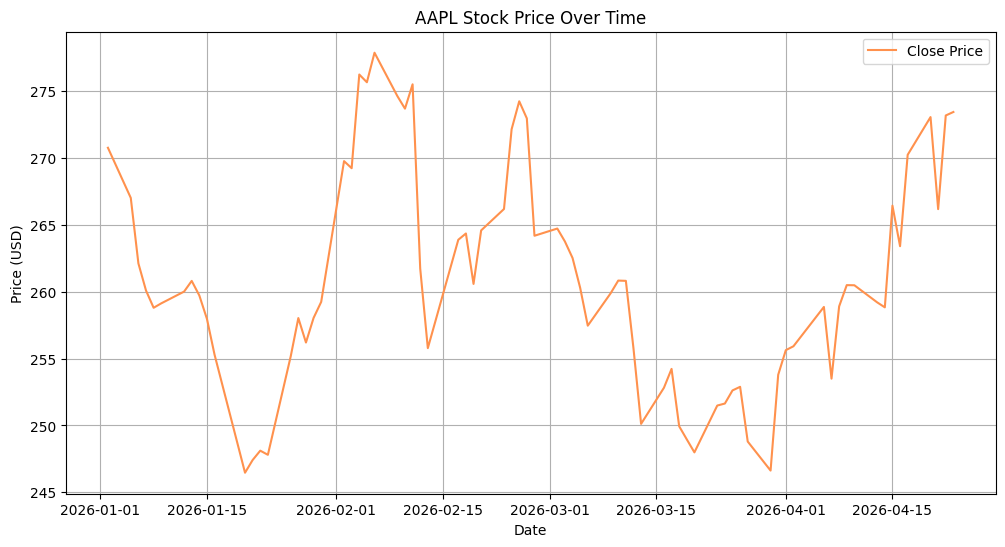

In [3]:
plt.figure(figsize=(12,6))
plt.plot(stock_data.index, stock_data['Close'], label='Close Price', color='#FF914D')
plt.title('AAPL Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

## Classical Time Series Decompostion

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition_additive = seasonal_decompose(stock_data['Close'], model='additive', period=30)

In [5]:
trend_additive = decomposition_additive.trend
seasonal_additive = decomposition_additive.seasonal
residual_additive = decomposition_additive.resid

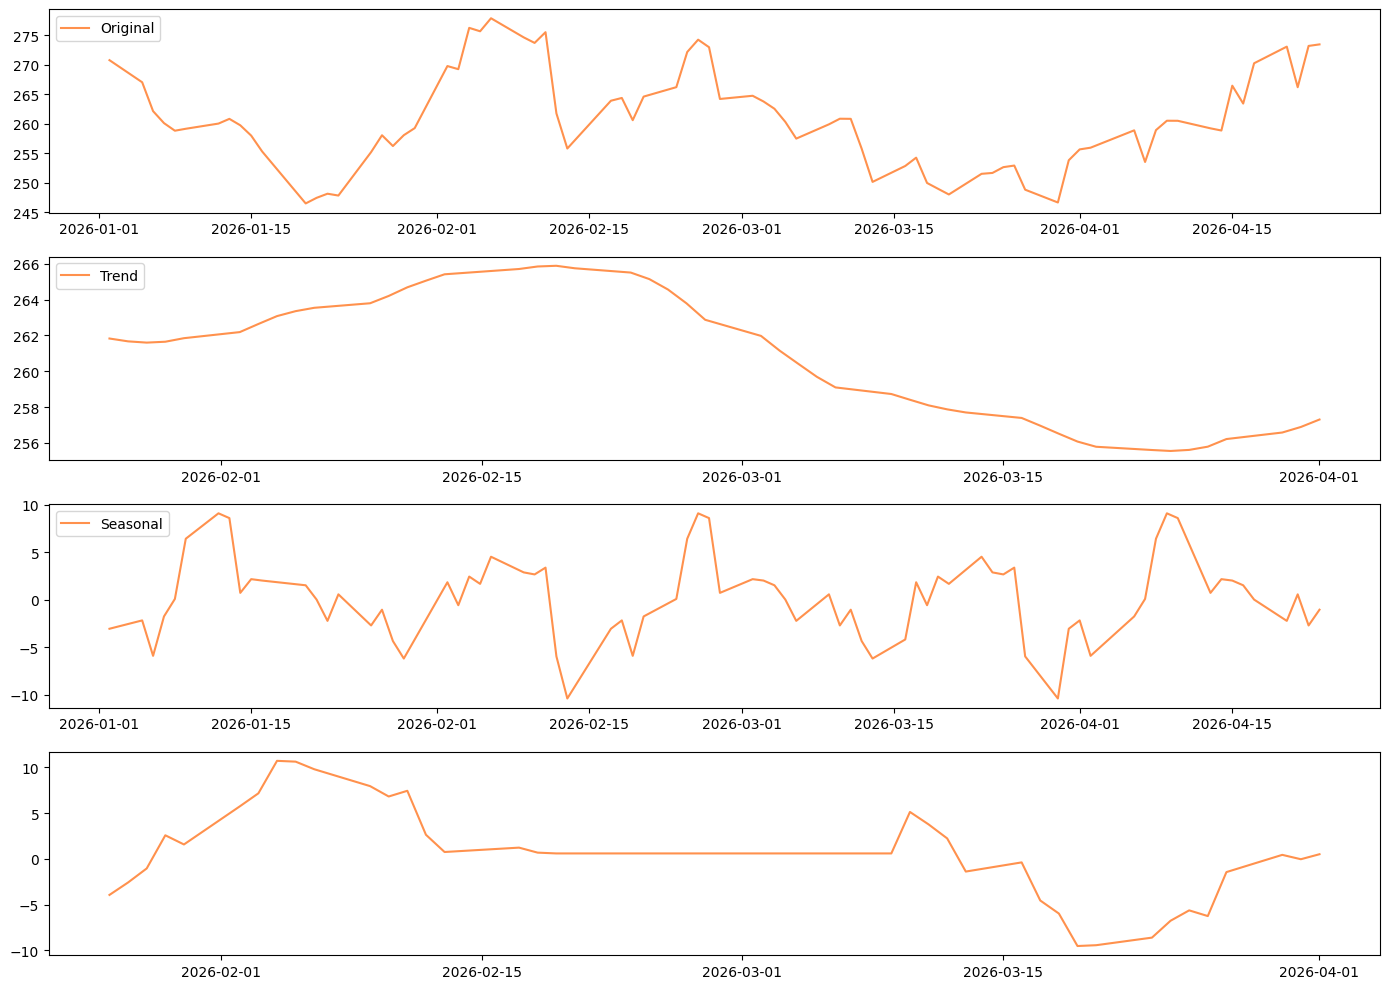

In [6]:
plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(stock_data['Close'], label='Original', color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend_additive, label='Trend', color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal_additive, label='Seasonal', color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(residual_additive, label='Residual', color='#FF914D')
plt.tight_layout()
plt.show()


## STL Decomposing

In [7]:
from statsmodels.tsa.seasonal import STL

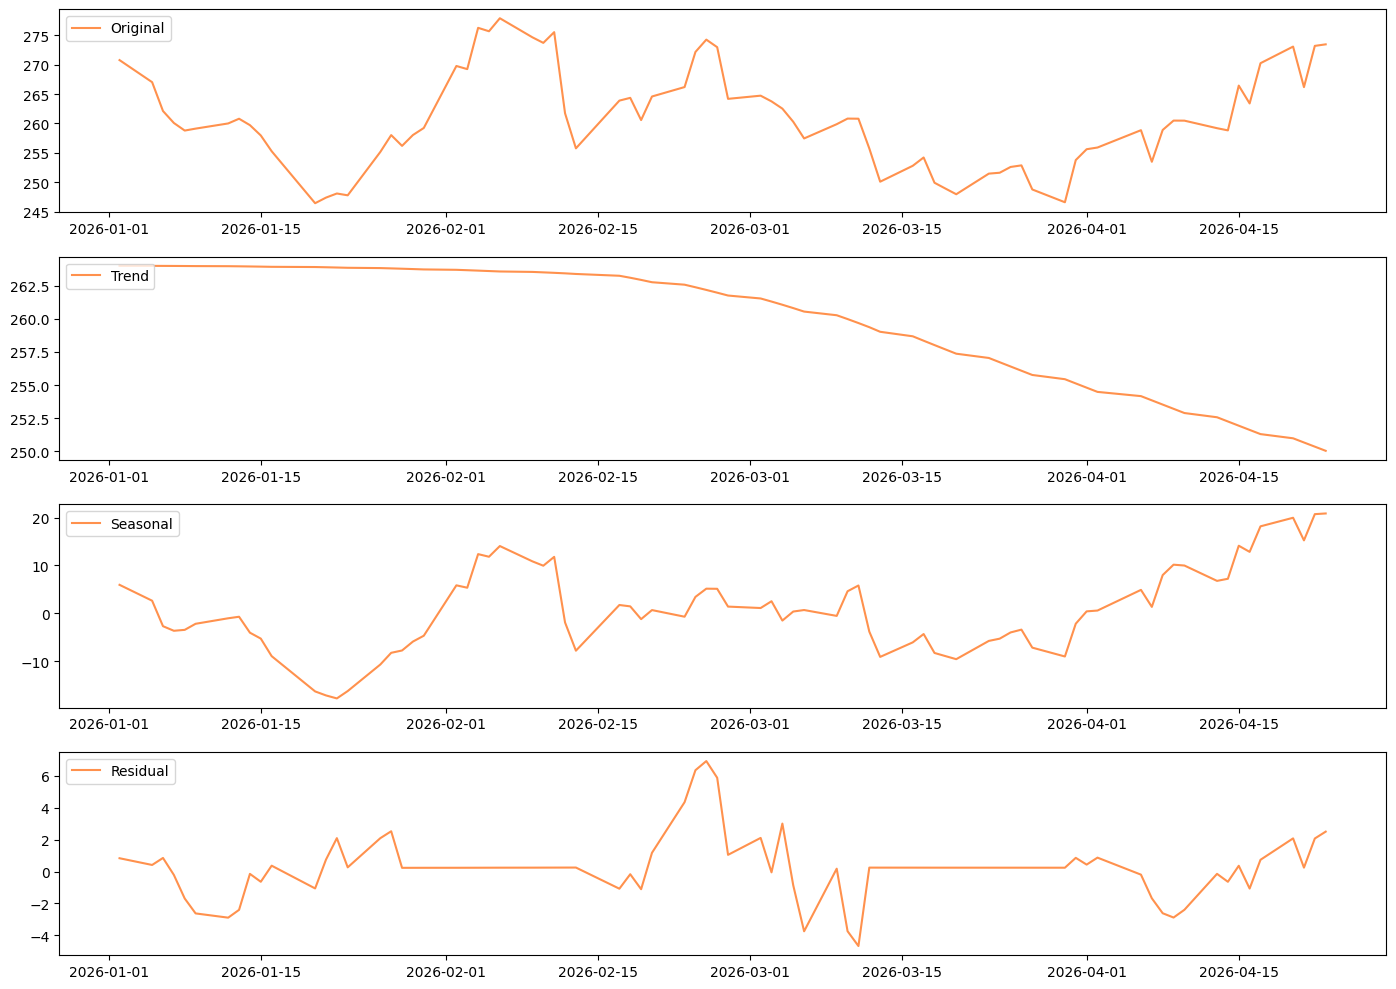

In [8]:
stl = STL(stock_data['Close'], period=30)
result = stl.fit()

plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(result.observed, label='Original', color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(result.trend, label='Trend', color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(result.seasonal, label='Seasonal', color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(result.resid, label='Residual', color='#FF914D')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Stationarity Test

In [9]:
from statsmodels.tsa.stattools import adfuller

# Perform the Augmented Dickey-fuller test
ad_test = adfuller(stock_data['Close'])

print('ADF Test Results: ')
print(f'ADF Statistic: {round(ad_test[0], 3)}')
print(f'p-value: {round(ad_test[1], 3)}')
print('Critical Values: ')
for key, value in ad_test[4].items():
    print(f'    {key}: {round(value,3)}')

ADF Test Results: 
ADF Statistic: -2.174
p-value: 0.216
Critical Values: 
    1%: -3.519
    5%: -2.9
    10%: -2.587


In [10]:
from statsmodels.tsa.stattools import kpss

# Perform the KPSS test
kpss_test = kpss(stock_data['Close'], regression='ct')  # 'c' for constant (level stationarity), 'ct' for trend

print('KPSS Test Results: ')
print(f'KPSS Statistic: {round(kpss_test[0], 2)}')
print(f'p-value: {kpss_test[1]}')
print('Critical Values:')
for key, value in kpss_test[3].items():
    print(f'    {key}: {value}')

KPSS Test Results: 
KPSS Statistic: 0.11
p-value: 0.1
Critical Values:
    10%: 0.119
    5%: 0.146
    2.5%: 0.176
    1%: 0.216


C:\Users\skaur\AppData\Local\Temp\ipykernel_30368\3327776410.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(stock_data['Close'], regression='ct')  # 'c' for constant (level stationarity), 'ct' for trend


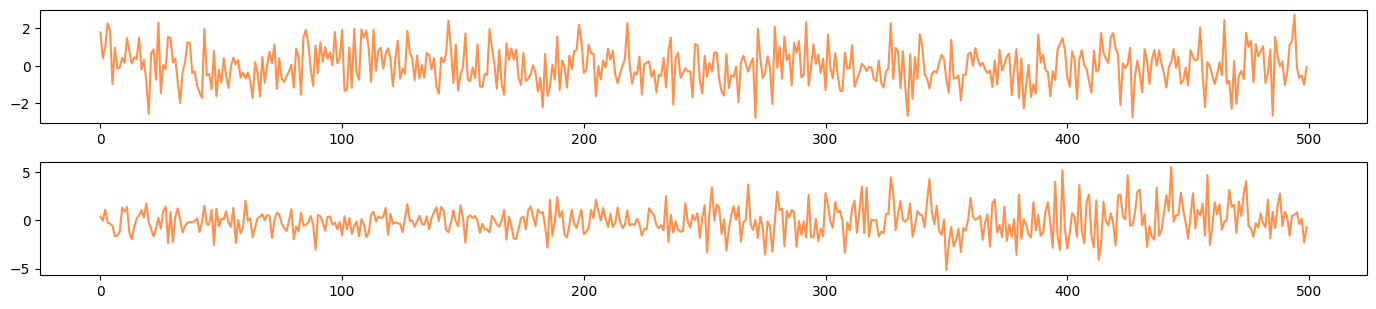

Strict Stationary Series - K-S Test Statistic: 0.068, p-value: 0.6109
Weak Stationary Series - K-S Test Statistic: 0.184, p-value: 0.0004


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Generating synthectic data for demonstration
np.random.seed(0)
n = 500

# Strictly staionary series: normally distributed random noise
strict_stationary_series = np.random.normal(0, 1, n)

# Non-strictly stationary series: changing variance
non_strict_stationary_series = np.concatenate([
    np.random.normal(0, 1, n // 2),
    np.random.normal(0, 2, n // 2)
])

# Function to split the series into two halves and perform the K-S test
def ks_test_stationarity(series):
    split = len(series) // 2
    series_first_half = series[:split]
    series_second_half = series[split:]
    stat, p_value = ks_2samp(series_first_half, series_second_half)
    return stat, p_value

# Perform the K-S test on strictly stationary series
ks_stat_strict, ks_pvalue_strict = ks_test_stationarity(strict_stationary_series)

# Perform the K-S test on non-strictly stationary series
ks_stat_non_strict, ks_pvalue_non_strict = ks_test_stationarity(non_strict_stationary_series)

# Plotting the series
plt.figure(figsize=(14, 6))
plt.subplot(411)
plt.plot(strict_stationary_series, label='Strict Stationary Series', color='#FF914D')
plt.subplot(412)
plt.plot(non_strict_stationary_series, label='Weak Stationary Series', color='#FF914D')
plt.tight_layout()
plt.show()

print(f'Strict Stationary Series - K-S Test Statistic: {ks_stat_strict}, p-value: {ks_pvalue_strict:.4f}')

print(f'Weak Stationary Series - K-S Test Statistic: {ks_stat_non_strict}, p-value: {ks_pvalue_non_strict:.4f}')

## Making Data Stationary

In [12]:
def adf_test(series):
    result = adfuller(series)
    print('ADF Statistics: ', result[0])
    print('p-value: ', result[1])
    for key, value in result[4].items():
        print('Critical Value (%s): %.3f' % (key, value))

def kpss_test(series):
    result = kpss(series, regression='c')
    print('KPSS Statistic: ', result[0])
    print('p-value: ', result[1])
    for key, value in result[4].items():
        print('Critical Value (%s): %.3f' % (key, value))

In [14]:
prices = stock_data['Close']

In [15]:
adf_test(prices)

ADF Statistics:  -2.1740427739370745
p-value:  0.21580093362241198
Critical Value (1%): -3.519
Critical Value (5%): -2.900
Critical Value (10%): -2.587


In [30]:
prices_diff = prices.diff()
adf_test(prices_diff.dropna())

ADF Statistics:  -8.708664749033492
p-value:  3.641255937613533e-14
Critical Value (1%): -3.521
Critical Value (5%): -2.901
Critical Value (10%): -2.588


In [18]:
prices

Ticker,AAPL
Date,
2026-01-02,270.756653
2026-01-05,267.010162
2026-01-06,262.114716
2026-01-07,260.086609
2026-01-08,258.797852
...,...
2026-04-17,270.230011
2026-04-20,273.049988
2026-04-21,266.170013


In [20]:
import numpy as np
from scipy import stats

# Log transformation
prices_log = np.log(prices)

# Square root transformation
prices_sqrt = np.sqrt(prices)

prices_1d = prices['AAPL']
# Box-Cox transformation
# Note: Box-Cox requires all positive values
prices_boxcox, lam = stats.boxcox(prices_1d[prices_1d > 0])

In [28]:
adf_test(prices_log)

ADF Statistics:  -2.1741448807524475
p-value:  0.21576282029949223
Critical Value (1%): -3.519
Critical Value (5%): -2.900
Critical Value (10%): -2.587


In [27]:
adf_test(prices_sqrt)

ADF Statistics:  -2.173895543545083
p-value:  0.2158558974645497
Critical Value (1%): -3.519
Critical Value (5%): -2.900
Critical Value (10%): -2.587


In [26]:
adf_test(prices_boxcox)

ADF Statistics:  -2.18422082808174
p-value:  0.21202214780958828
Critical Value (1%): -3.519
Critical Value (5%): -2.900
Critical Value (10%): -2.587


In [31]:
from scipy import signal

# Using a linear trend
trend = np.polyfit(np.arange(len(prices_1d)), prices_1d, 1)
trendline = np.polyval(trend, np.arange(len(prices_1d)))
prices_detrended = prices_1d - trendline

In [32]:
adf_test(prices_detrended)

ADF Statistics:  -2.119203260752987
p-value:  0.2368633082276297
Critical Value (1%): -3.519
Critical Value (5%): -2.900
Critical Value (10%): -2.587


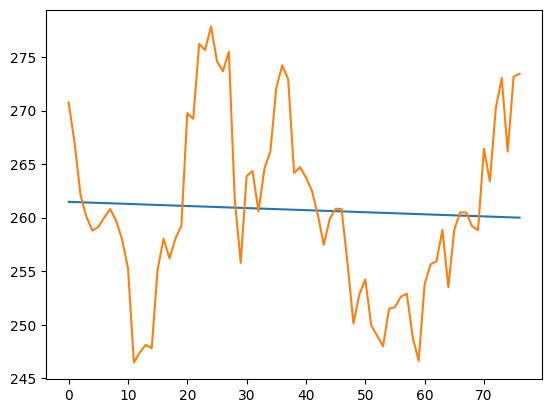

In [37]:
plt.plot(np.arange(len(prices)), trendline)
plt.plot(np.arange(len(prices)), prices)
plt.show()

In [33]:
# Using moving average to remove trend
window = 12
prices_na = prices.rolling(window=window).mean()
prices_detrended = prices - prices_na
prices_detrended = prices_detrended.dropna()

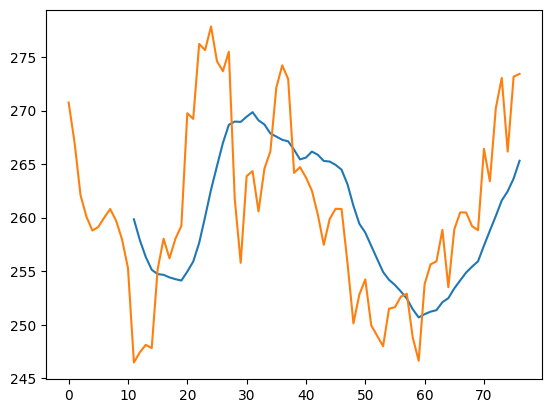

In [38]:
plt.plot(np.arange(len(prices)), prices_na)
plt.plot(np.arange(len(prices)), prices)
plt.show()

In [40]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Seasonal decomposition using moving averages
decomposition = seasonal_decompose(prices_1d, model='additive', period=30)
prices_adjusted = prices_1d / decomposition.seasonal
prices_adjusted = prices_adjusted.dropna()

In [41]:
adf_test(prices_adjusted)

ADF Statistics:  -9.102565493726523
p-value:  3.572889962758349e-15
Critical Value (1%): -3.519
Critical Value (5%): -2.900
Critical Value (10%): -2.587
